# Data Splitting and Processing
This notebook provides a comprehensive guide to data preprocessing, covering:
- Loading data
- Handling missing values
- Encoding categorical variables
- Scaling features
- Visualizing data
- Splitting into train and test sets

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

# Display options for better readability
pd.set_option('display.float_format', '{:.2f}'.format)

## 1. Loading Data
Let's start by creating a sample dataset with missing values and categorical data. This data will be used for the subsequent steps.

In [3]:
data = pd.DataFrame({
    'Price': [150.25, None, 2800.10, 450.50, None, 120.75, 330.00, 190.40, None, 510.20],
    'Volume': [1200000, 4500000, None, 300000, 1500000, None, 800000, 2100000, 3500000, None],
    'MarketCap_B': [450.5, 1200.2, 550.0, None, 88.4, 210.3, None, 15.6, 740.0, 110.5],
    'Sector': ['Tech', 'Finance', 'Tech', 'Energy', 'Finance', 'Health', None, 'Retail', 'Tech', 'Health'],
    'EPS': [4.5, None, 12.1, 1.8, 3.2, 0.9, 4.4, None, 5.6, 2.7]
})

print('Initial Dataset:')
data

Initial Dataset:


,Price,Volume,MarketCap_B,Sector,EPS
0,150.25,1200000.00,450.50,Tech,4.50
1,NaN,4500000.00,1200.20,Finance,NaN
2,2800.10,NaN,550.00,Tech,12.10
3,450.50,300000.00,NaN,Energy,1.80
4,NaN,1500000.00,88.40,Finance,3.20
5,120.75,NaN,210.30,Health,0.90
6,330.00,800000.00,NaN,NaN,4.40
7,190.40,2100000.00,15.60,Retail,NaN
8,NaN,3500000.00,740.00,Tech,5.60
9,510.20,NaN,110.50,Health,2.70


## 2. Handling Missing Values
We'll handle missing values by:
- Filling `Age` with the median
- Filling `Height` and `Weight` with the mean
- Filling `Score` with a constant value of 0


In [6]:
# Handle missing values
data['Price'] = data['Price'].fillna(data['Price'].median())                  # Median for 'Price'
data['Volume'] = data['Volume'].fillna(data['Volume'].mean())                  # Mean for 'Volume'
data['MarketCap_B'] = data['MarketCap_B'].fillna(data['MarketCap_B'].mean())   # Mean for 'MarketCap_B'
data['EPS'] = data['EPS'].fillna(0)                                            # Constant (0) for 'EPS'

print('Data After Handling Missing Values:')
data

Data After Handling Missing Values:


,Price,Volume,MarketCap_B,Sector,EPS,Price
0,150.25,1200000.00,450.50,Tech,4.50,150.25
1,330.00,4500000.00,1200.20,Finance,0.00,330.00
2,2800.10,1985714.29,550.00,Tech,12.10,2800.10
3,450.50,300000.00,420.69,Energy,1.80,450.50
4,330.00,1500000.00,88.40,Finance,3.20,330.00
5,120.75,1985714.29,210.30,Health,0.90,120.75
6,330.00,800000.00,420.69,NaN,4.40,330.00
7,190.40,2100000.00,15.60,Retail,0.00,190.40
8,330.00,3500000.00,740.00,Tech,5.60,330.00
9,510.20,1985714.29,110.50,Health,2.70,510.20


## 3. Encoding Categorical Variables
For categorical data, we'll use one-hot encoding to convert the `Sector` column into numerical format.

In [7]:
data = pd.get_dummies(data, columns=['Sector'], drop_first=True)
print('Data After One-Hot Encoding:')
data

Data After One-Hot Encoding:


,Price,Volume,MarketCap_B,EPS,Price,Sector_Finance,Sector_Health,Sector_Retail,Sector_Tech
0,150.25,1200000.00,450.50,4.50,150.25,False,False,False,True
1,330.00,4500000.00,1200.20,0.00,330.00,True,False,False,False
2,2800.10,1985714.29,550.00,12.10,2800.10,False,False,False,True
3,450.50,300000.00,420.69,1.80,450.50,False,False,False,False
4,330.00,1500000.00,88.40,3.20,330.00,True,False,False,False
5,120.75,1985714.29,210.30,0.90,120.75,False,True,False,False
6,330.00,800000.00,420.69,4.40,330.00,False,False,False,False
7,190.40,2100000.00,15.60,0.00,190.40,False,False,True,False
8,330.00,3500000.00,740.00,5.60,330.00,False,False,False,True
9,510.20,1985714.29,110.50,2.70,510.20,False,True,False,False


## 4. Scaling the Data
We'll scale the numerical columns using **Standard Scaling** to make features have a mean of 0 and standard deviation of 1.

In [8]:
scaler = StandardScaler()
data[['Price', 'Volume', 'MarketCap_B', 'EPS']] = scaler.fit_transform(data[['Price', 'Volume', 'MarketCap_B', 'EPS']])

print('Data After Standard Scaling:')
data

Data After Standard Scaling:


,Price,Volume,MarketCap_B,EPS,Price,Sector_Finance,Sector_Health,Sector_Retail,Sector_Tech
0,-0.53,-0.67,0.09,0.29,150.25,False,False,False,True
1,-0.30,2.15,2.31,-1.04,330.00,True,False,False,False
2,2.96,-0.00,0.38,2.53,2800.10,False,False,False,True
3,-0.14,-1.44,0.00,-0.51,450.50,False,False,False,False
4,-0.30,-0.41,-0.98,-0.09,330.00,True,False,False,False
5,-0.57,-0.00,-0.62,-0.77,120.75,False,True,False,False
6,-0.30,-1.01,0.00,0.26,330.00,False,False,False,False
7,-0.48,0.10,-1.20,-1.04,190.40,False,False,True,False
8,-0.30,1.29,0.94,0.61,330.00,False,False,False,True
9,-0.06,-0.00,-0.92,-0.24,510.20,False,True,False,False


## 5. Visualizing the Data
Visualizations help understand distributions and correlations among variables. Here, we'll use histograms and a heatmap to explore data distribution and correlations.

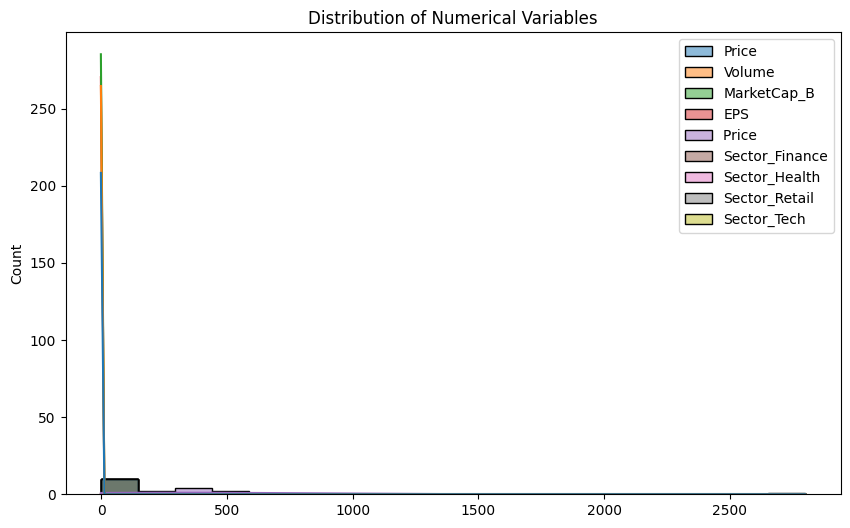

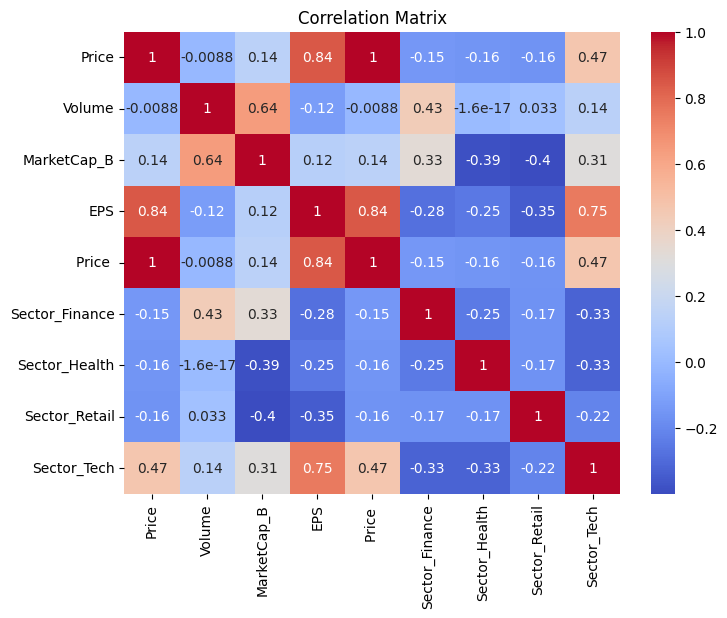

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(data, kde=True)
plt.title('Distribution of Numerical Variables')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## 6. Splitting Data into Training and Testing Sets
Finally, we split the data into training and testing sets, with 80% for training and 20% for testing.

In [10]:
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

print('Training Data:')
print(train_data)

print('Testing Data:')
print(test_data)

Training Data:
   Price  Volume  MarketCap_B   EPS  Price   Sector_Finance  Sector_Health  \
5  -0.57   -0.00        -0.62 -0.77  120.75           False           True   
0  -0.53   -0.67         0.09  0.29  150.25           False          False   
7  -0.48    0.10        -1.20 -1.04  190.40           False          False   
2   2.96   -0.00         0.38  2.53 2800.10           False          False   
9  -0.06   -0.00        -0.92 -0.24  510.20           False           True   
4  -0.30   -0.41        -0.98 -0.09  330.00            True          False   
3  -0.14   -1.44         0.00 -0.51  450.50           False          False   
6  -0.30   -1.01         0.00  0.26  330.00           False          False   

   Sector_Retail  Sector_Tech  
5          False        False  
0          False         True  
7           True        False  
2          False         True  
9          False        False  
4          False        False  
3          False        False  
6          False        Fa